In [1]:
import pandas as pd
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [2]:
corpora = pd.read_parquet("../../corpora/GeneratedCorpus/corpora_v3.parquet")
corpora = corpora.reset_index(names='text_id')


results = pd.DataFrame()
for res in glob("./results5/*"):
    temp = pd.read_csv(res)
    results = pd.concat([results, temp])


df = pd.merge(results, corpora)


model_order = [
    "Manaca",
    "Tucano-2b4",
    "Cabrita",
    "Sabia 7B",
    "Llama3.1",
    "Qwen3.5-9B",
    "Gemma4-12B",
]

df["model"] = pd.Categorical(
    df["model"],
    categories=model_order,
    ordered=True
)

df = df.sort_values("model")

# df = df[~df["scenario"].isin(["GRAMMAR SWAP", "GRAMMAR SWAP v2"])]
df = df[df["language"].isin(["INGLÊS", "ESPANHOL", "PB NATIVO"])]

# Analise de perplexidade e BPB dos modelos

In [3]:
ppl = df.groupby(["model"])["ppl"].describe().sort_values(by='mean')
display(ppl)
# ppl = ppl["mean"].to_dict()

,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
Sabia 7B,852.00,17.83,16.79,2.24,8.57,12.15,18.70,147.77
Llama3.1,852.00,25.34,28.76,3.37,10.27,15.54,25.65,217.51
Gemma4-12B,852.00,37.61,58.86,3.50,12.61,19.33,33.75,556.14
Qwen3.5-9B,852.00,41.44,64.52,4.99,13.65,21.63,36.47,550.20
Cabrita,852.00,48.00,70.47,4.39,16.84,25.52,42.21,593.76
Tucano-2b4,852.00,64.29,121.83,2.56,13.98,24.52,46.06,974.30
Manaca,852.00,98.74,195.62,3.57,23.14,37.13,64.93,1669.60


In [4]:
bpb = df.groupby(["model"])["bpb"].describe().sort_values(by='mean')
display(bpb)
bpb = bpb["mean"].to_dict()

,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
Gemma4-12B,852.00,1.06,0.30,0.35,0.85,1.00,1.18,2.09
Qwen3.5-9B,852.00,1.09,0.31,0.44,0.87,1.04,1.22,2.13
Llama3.1,852.00,1.11,0.32,0.43,0.89,1.05,1.24,2.21
Sabia 7B,852.00,1.14,0.31,0.31,0.94,1.08,1.27,2.21
Tucano-2b4,852.00,1.21,0.31,0.23,1.00,1.15,1.36,2.22
Manaca,852.00,1.27,0.30,0.30,1.07,1.22,1.43,2.23
Cabrita,852.00,1.28,0.31,0.48,1.08,1.23,1.41,2.27


/tmp/ipykernel_19113/1101959305.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_19113/1101959305.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


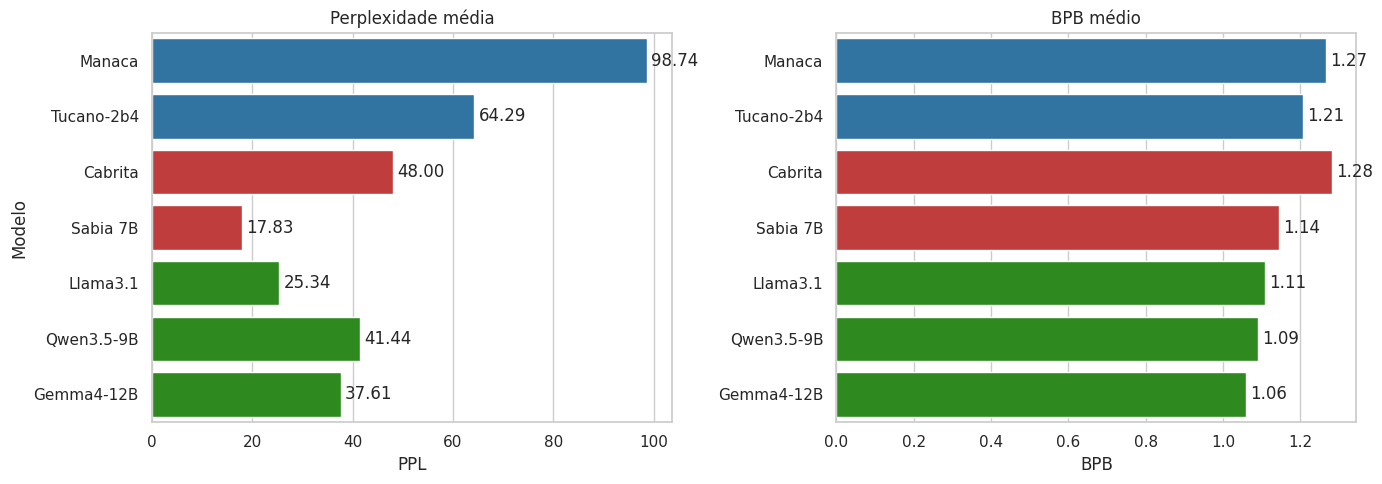

In [15]:
palette = {
    "Sabia 7B": "tab:red",
    "Gemma4-12B": "#229c0c",
    "Llama3.1": "#229c0c",
    "Qwen3.5-9B": "#229c0c",
    "Cabrita": "tab:red",
    "Tucano-2b4": "tab:blue",
    "Manaca": "tab:blue"
}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=df,
    x="ppl", y="model", orient="h",
    estimator="mean", errorbar=None,
    palette=palette,
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Perplexidade média")
axes[0].set_xlabel("PPL")
axes[0].set_ylabel("Modelo")
for container in axes[0].containers:
    axes[0].bar_label(container,fmt="%.2f", padding=3)

sns.barplot(
    data=df,
    x="bpb", y="model", orient="h",
    estimator="mean", errorbar=None,
    palette=palette, 
    legend=False,
    ax=axes[1]
)

axes[1].set_title("BPB médio")
axes[1].set_xlabel("BPB")
axes[1].set_ylabel("")
for container in axes[1].containers:
    axes[1].bar_label(container,fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()

# Versões do Grammar Swap

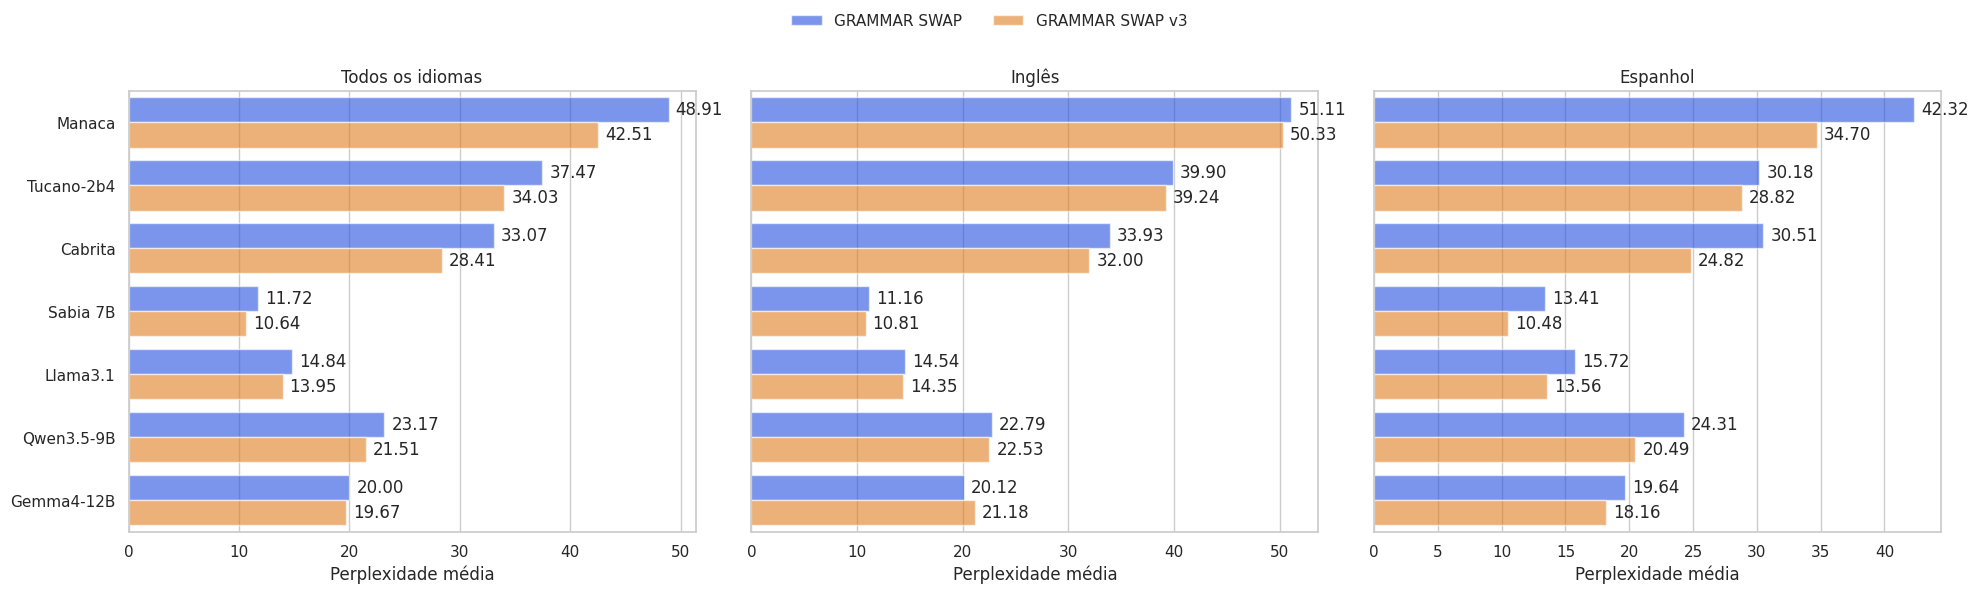

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

scenarios = ["GRAMMAR SWAP", "GRAMMAR SWAP v3"]

fig, axes = plt.subplots(
    1, 3,
    figsize=(20, 6),
    sharey=True
)

configs = [
    ("Todos os idiomas", None),
    ("Inglês", "INGLÊS"),
    ("Espanhol", "ESPANHOL"),
]

for ax, (title, language) in zip(axes, configs):

    plot_df = df[
        df["scenario"].isin(scenarios)
    ].copy()

    if language is not None:
        plot_df = plot_df[plot_df["language"] == language]

    sns.barplot(
        data=plot_df,
        y="model", x="ppl", hue="scenario",
        estimator="mean", errorbar=None,
        palette="bright",
        alpha=.6, orient="h", ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel("Perplexidade média")
    ax.set_ylabel("")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=5)

    # Remove legenda individual
    if ax.get_legend():
        ax.get_legend().remove()


# Legenda única
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.92])

plt.show()

## Análise dos modelos nos diferentes cenários

In [20]:
for lang in (None, "INGLÊS", "ESPANHOL"):
    print(lang if lang is not None else "Ambas")

    for metric in ["bpb", "ppl"]:
        models_results = {
            "PB NATIVO": [],
            "TRANSLATION": [],
            "LEXICAL SWAP": [],
            "GRAMMAR SWAP v3": [],
            "PB CORRUPTED": [],
            "PB PERMUTED": [],
        }
        scenarios = list(models_results.keys())
        models_results["model"] = []


        for model in df["model"].unique().tolist():
            models_results["model"].append(model)

            for scenario in scenarios:
                temp_df = df.copy()
                if lang is not None:
                    temp_df = temp_df[temp_df["language"] == lang]

                value = temp_df[(temp_df["scenario"] == scenario) & (temp_df["model"] == model)][metric].mean()

                models_results[scenario].append(value)

        models_results_df = pd.DataFrame(models_results)

        # Making "model" the first column
        column_to_move = models_results_df.pop('model')
        models_results_df.insert(0, 'model', column_to_move)

        print(metric.upper())
        display(models_results_df)
        print("\n\n")

Ambas
BPB


,model,PB NATIVO,TRANSLATION,LEXICAL SWAP,GRAMMAR SWAP v3,PB CORRUPTED,PB PERMUTED
0,Manaca,0.99,1.23,1.37,1.10,1.37,1.85
1,Tucano-2b4,0.97,1.08,1.25,1.07,1.42,1.82
2,Cabrita,1.13,1.08,1.25,1.20,1.57,1.90
3,Sabia 7B,0.99,0.93,1.13,1.06,1.41,1.79
4,Llama3.1,1.01,0.85,1.08,1.04,1.40,1.76
5,Qwen3.5-9B,0.97,0.85,1.07,1.02,1.37,1.73
6,Gemma4-12B,0.93,0.83,1.02,0.99,1.33,1.69





PPL


,model,PB NATIVO,TRANSLATION,LEXICAL SWAP,GRAMMAR SWAP v3,PB CORRUPTED,PB PERMUTED
0,Manaca,32.93,22.79,39.30,42.51,131.31,585.13
1,Tucano-2b4,24.73,11.55,18.37,34.03,94.60,369.46
2,Cabrita,23.21,16.70,30.97,28.41,69.28,210.55
3,Sabia 7B,9.29,10.55,20.70,10.64,22.93,54.41
4,Llama3.1,13.64,11.77,27.79,13.95,34.86,88.42
5,Qwen3.5-9B,19.51,13.66,33.10,21.51,56.42,187.81
6,Gemma4-12B,17.00,13.00,28.86,19.67,51.15,171.43





INGLÊS
BPB


...

,model,PB NATIVO,TRANSLATION,LEXICAL SWAP,GRAMMAR SWAP v3,PB CORRUPTED,PB PERMUTED
0,Manaca,NaN,24.94,48.51,50.33,NaN,NaN
1,Tucano-2b4,NaN,10.54,19.59,39.24,NaN,NaN
2,Cabrita,NaN,18.79,43.21,32.00,NaN,NaN
3,Sabia 7B,NaN,11.68,27.35,10.81,NaN,NaN
4,Llama3.1,NaN,14.01,37.09,14.35,NaN,NaN
5,Qwen3.5-9B,NaN,14.42,39.62,22.53,NaN,NaN
6,Gemma4-12B,NaN,13.44,32.37,21.18,NaN,NaN





ESPANHOL
BPB


,model,PB NATIVO,TRANSLATION,LEXICAL SWAP,GRAMMAR SWAP v3,PB CORRUPTED,PB PERMUTED
0,Manaca,NaN,1.23,1.30,1.09,NaN,NaN
1,Tucano-2b4,NaN,1.08,1.18,1.06,NaN,NaN
2,Cabrita,NaN,1.18,1.26,1.18,NaN,NaN
3,Sabia 7B,NaN,0.98,1.10,1.06,NaN,NaN
4,Llama3.1,NaN,0.87,1.06,1.04,NaN,NaN
5,Qwen3.5-9B,NaN,0.86,1.03,1.03,NaN,NaN
6,Gemma4-12B,NaN,0.84,0.99,0.99,NaN,NaN





PPL


,model,PB NATIVO,TRANSLATION,LEXICAL SWAP,GRAMMAR SWAP v3,PB CORRUPTED,PB PERMUTED
0,Manaca,NaN,20.63,30.09,34.70,NaN,NaN
1,Tucano-2b4,NaN,12.57,17.15,28.82,NaN,NaN
2,Cabrita,NaN,14.61,18.74,24.82,NaN,NaN
3,Sabia 7B,NaN,9.43,14.06,10.48,NaN,NaN
4,Llama3.1,NaN,9.54,18.50,13.56,NaN,NaN
5,Qwen3.5-9B,NaN,12.89,26.57,20.49,NaN,NaN
6,Gemma4-12B,NaN,12.56,25.35,18.16,NaN,NaN


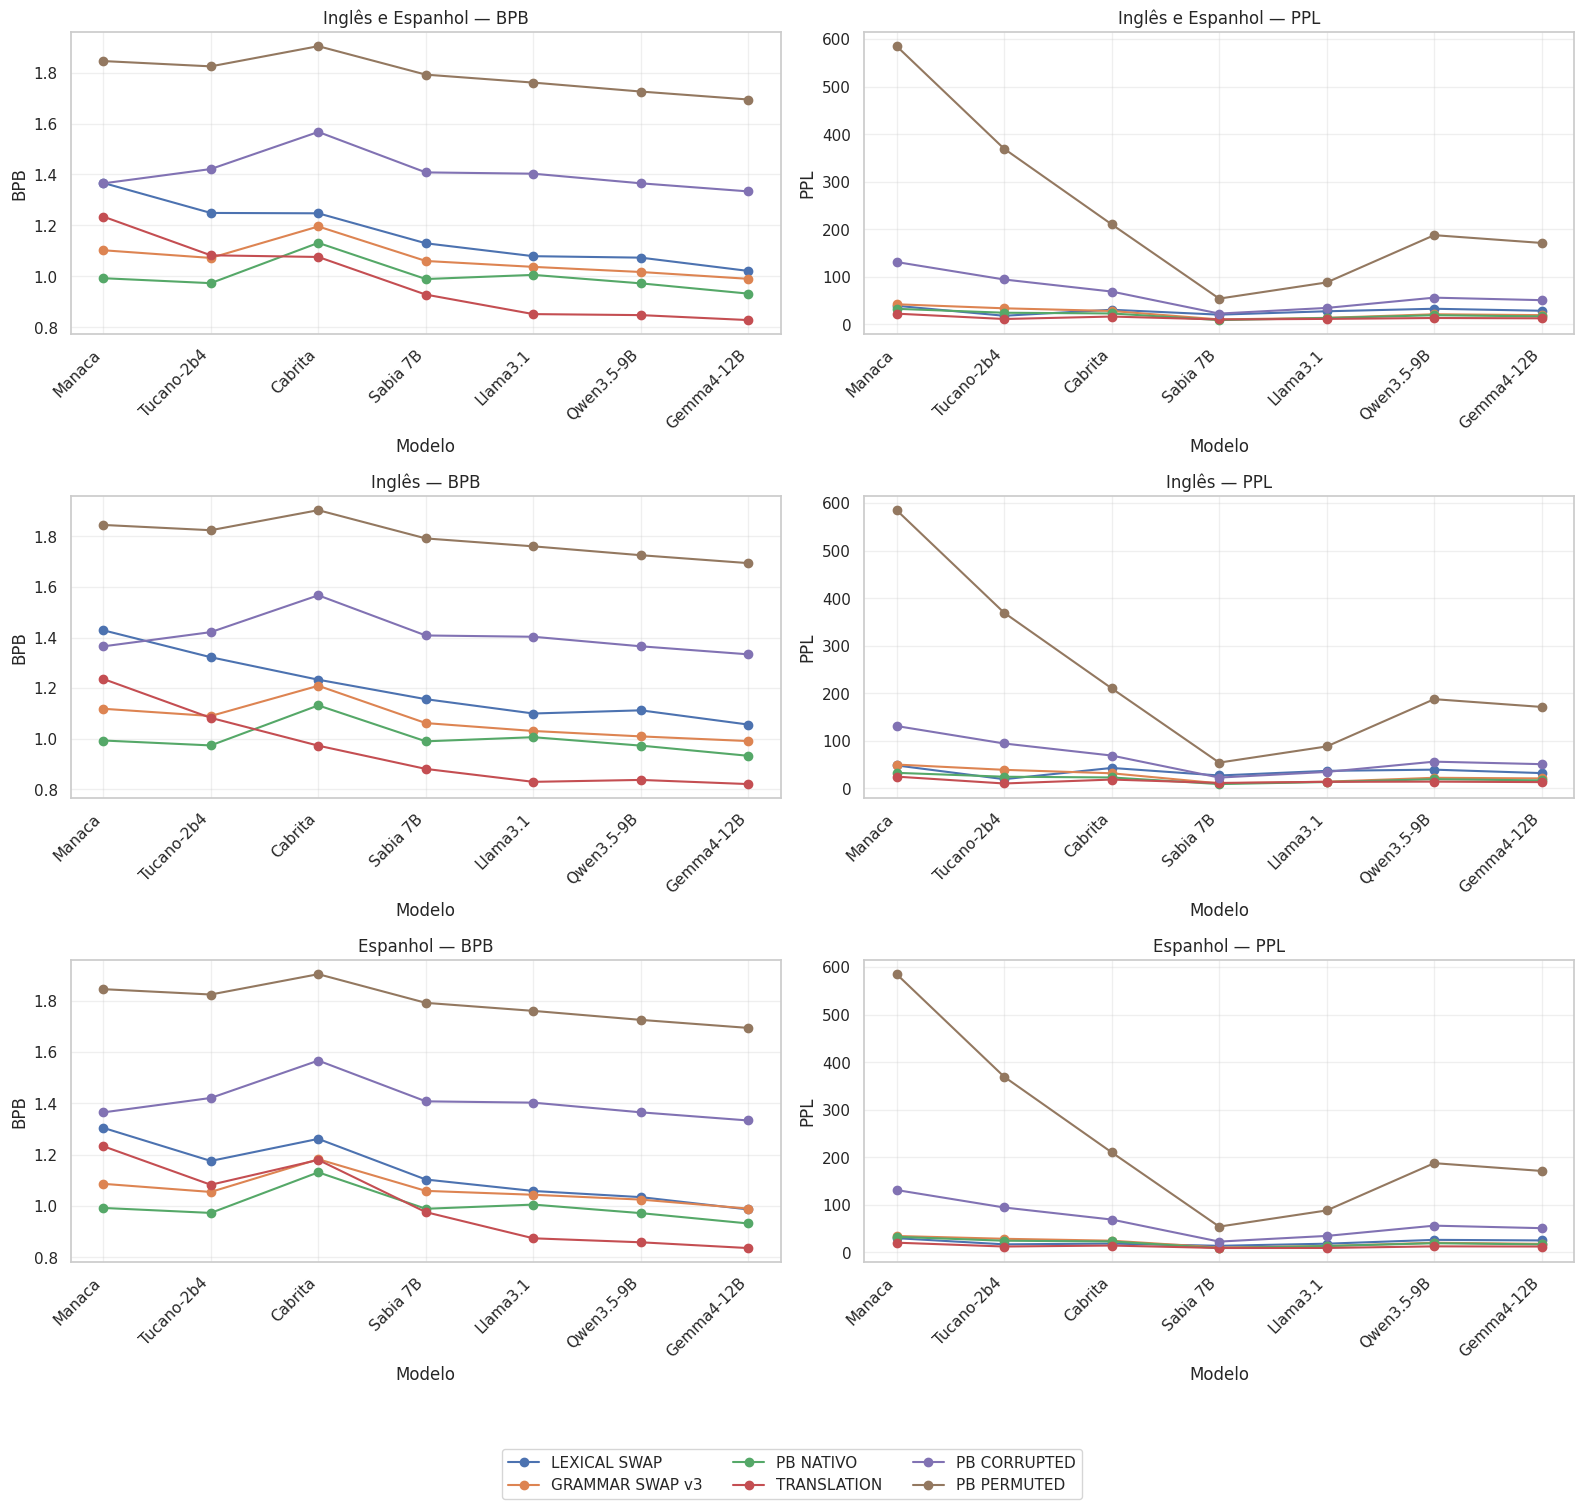

In [17]:
def plot_results(scenarios=["LEXICAL SWAP","GRAMMAR SWAP v3","PB NATIVO","TRANSLATION","PB CORRUPTED","PB PERMUTED"], confidence_bands=False):

    models = df["model"].unique()
    x = range(len(models))

    metrics = ["bpb", "ppl"]

    language_configs = [
        ("Inglês e Espanhol", None),
        ("Inglês", "INGLÊS"),
        ("Espanhol", "ESPANHOL"),
    ]

    fig, axes = plt.subplots(3,2,figsize=(16, 15),sharex=False)

    for row, (language_title, language) in enumerate(language_configs):

        if language is None:
            plot_df = df.copy()
        else:
            plot_df = df[df["language"].isin(["PB NATIVO", language])].copy()

        for col, metric in enumerate(metrics):

            ax = axes[row, col]

            for scenario in scenarios:
                y = []
                bands = []

                for model in models:
                    value = plot_df[(plot_df["scenario"] == scenario) & (plot_df["model"] == model)][metric]

                    y.append(value.mean())
                    bands.append(value.std())

                y = np.array(y)
                bands = np.array(bands)

                line, = ax.plot(x, y, marker="o", label=scenario)

                if confidence_bands:
                    ax.fill_between(x,y - bands,y + bands,alpha=0.2,color=line.get_color())

            ax.set_xticks(x)
            ax.set_xticklabels(models, rotation=45, ha="right")

            ax.set_xlabel("Modelo")
            ax.set_ylabel(metric.upper())

            ax.set_title(f"{language_title} — {metric.upper()}")

            ax.grid(alpha=0.3)

    # Legenda única para todos os gráficos
    handles, labels = axes[0, 0].get_legend_handles_labels()

    fig.legend(handles, labels, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.01))

    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.show()


plot_results()

- O português permutado tem os piores valores
- Em seguida vem o corrompido
- Manaca tem menos dificuldade, no BPB, no PB corrompido do que na troca lexical para o inglês
    - Mais preferência pelo léxico

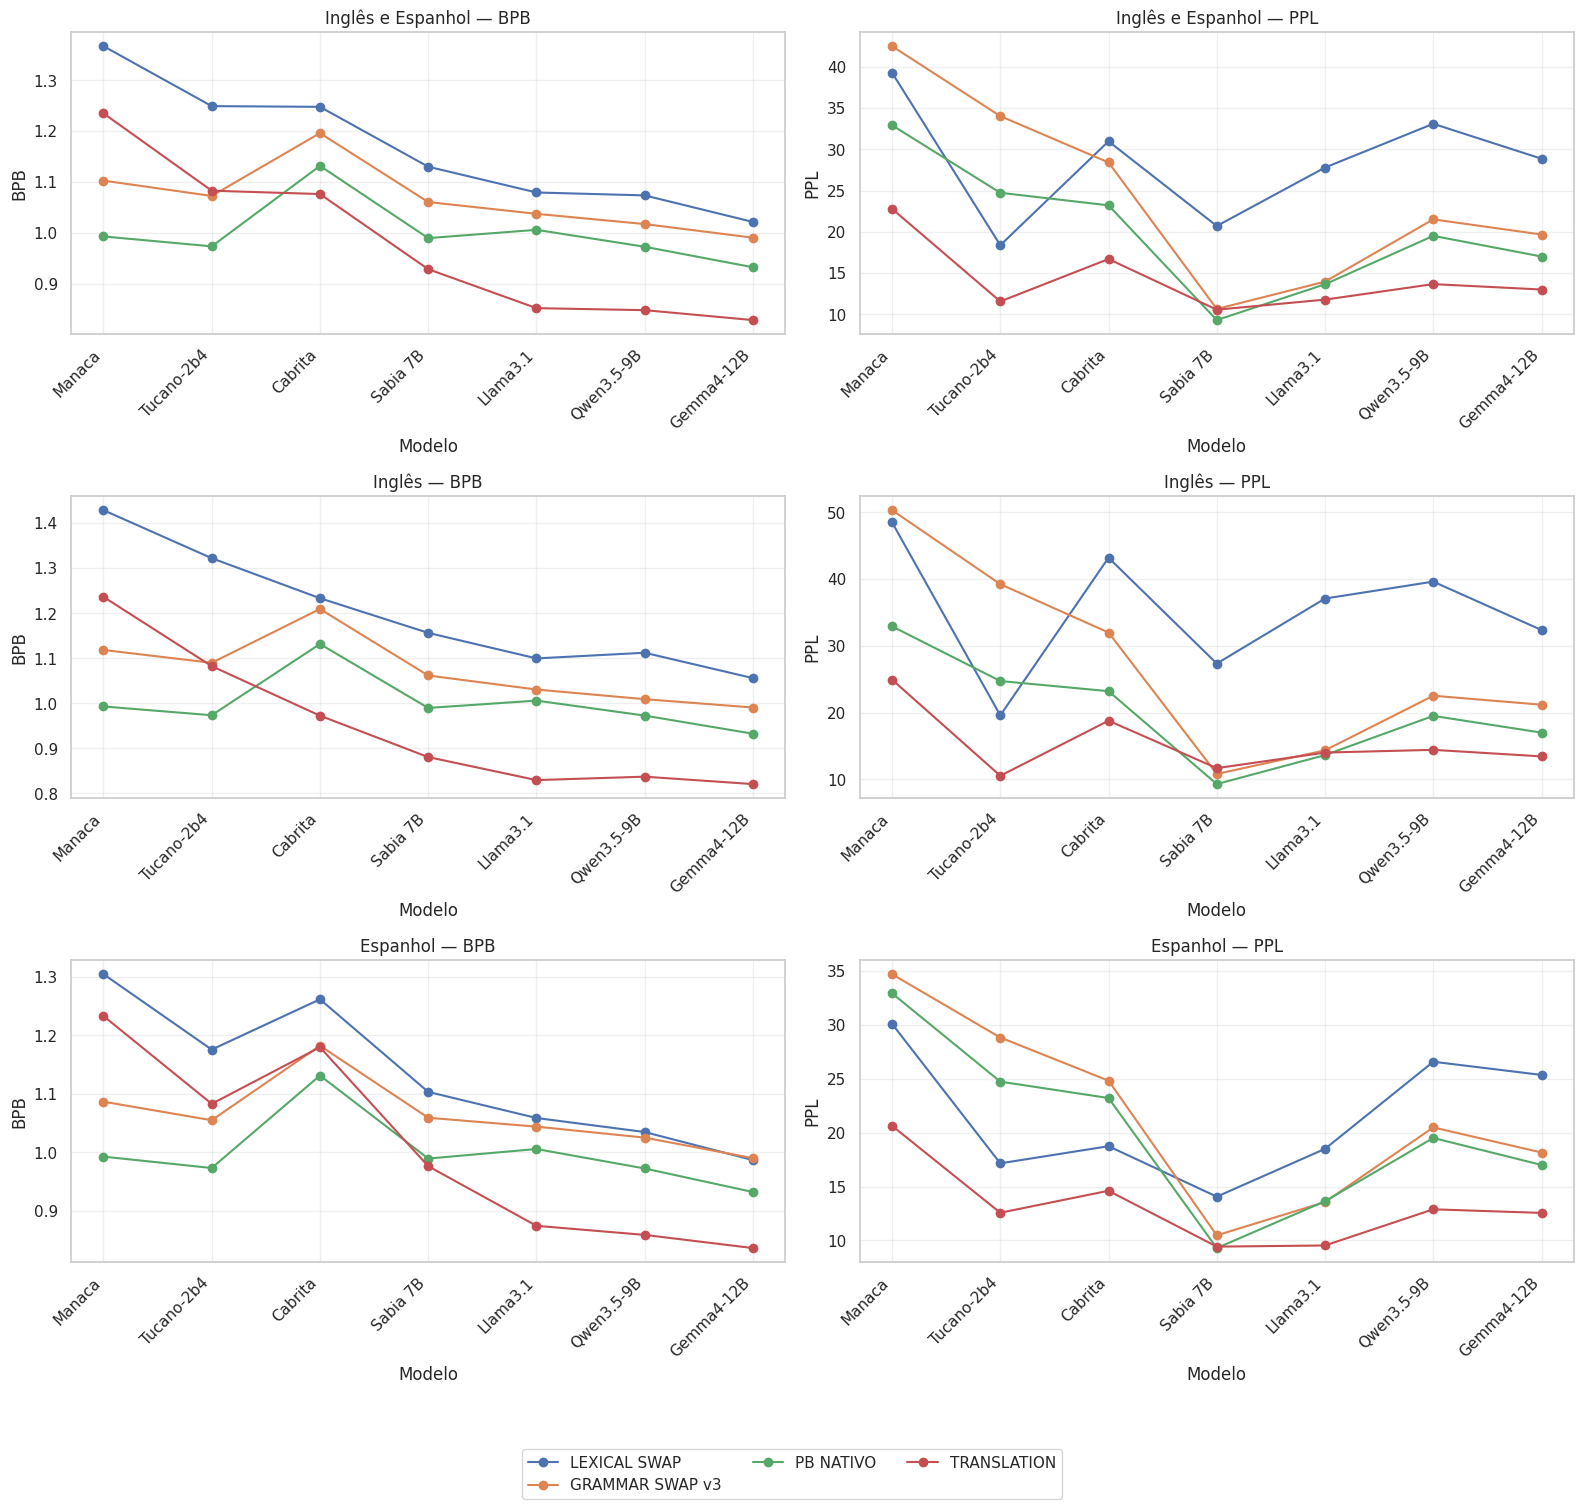

In [9]:
plot_results(scenarios =["LEXICAL SWAP","GRAMMAR SWAP v3","PB NATIVO","TRANSLATION"])

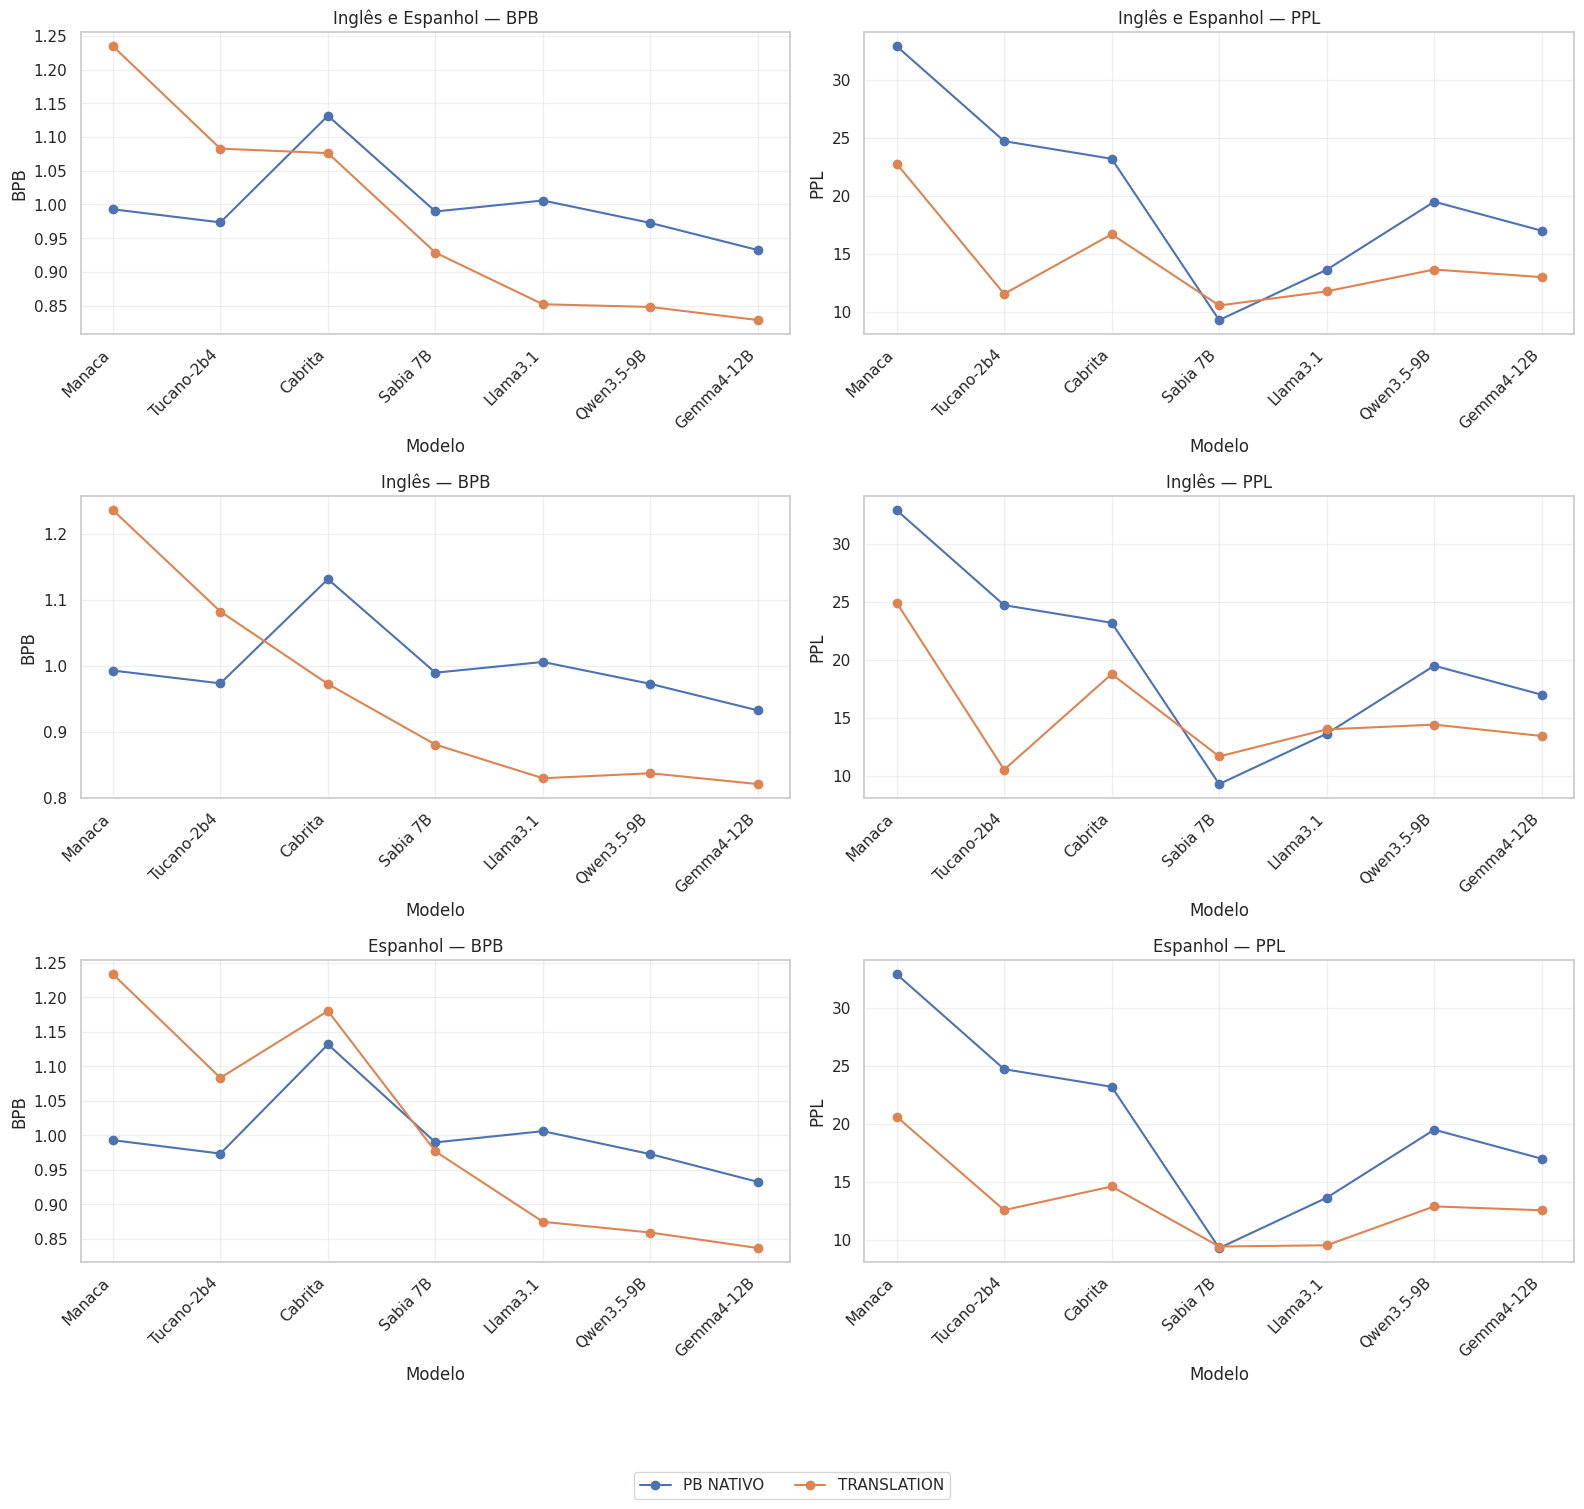

In [22]:
plot_results(scenarios =["PB NATIVO", "TRANSLATION"])

Quanto mais multilíngue o modelo vai ficando, menor o BPB fica

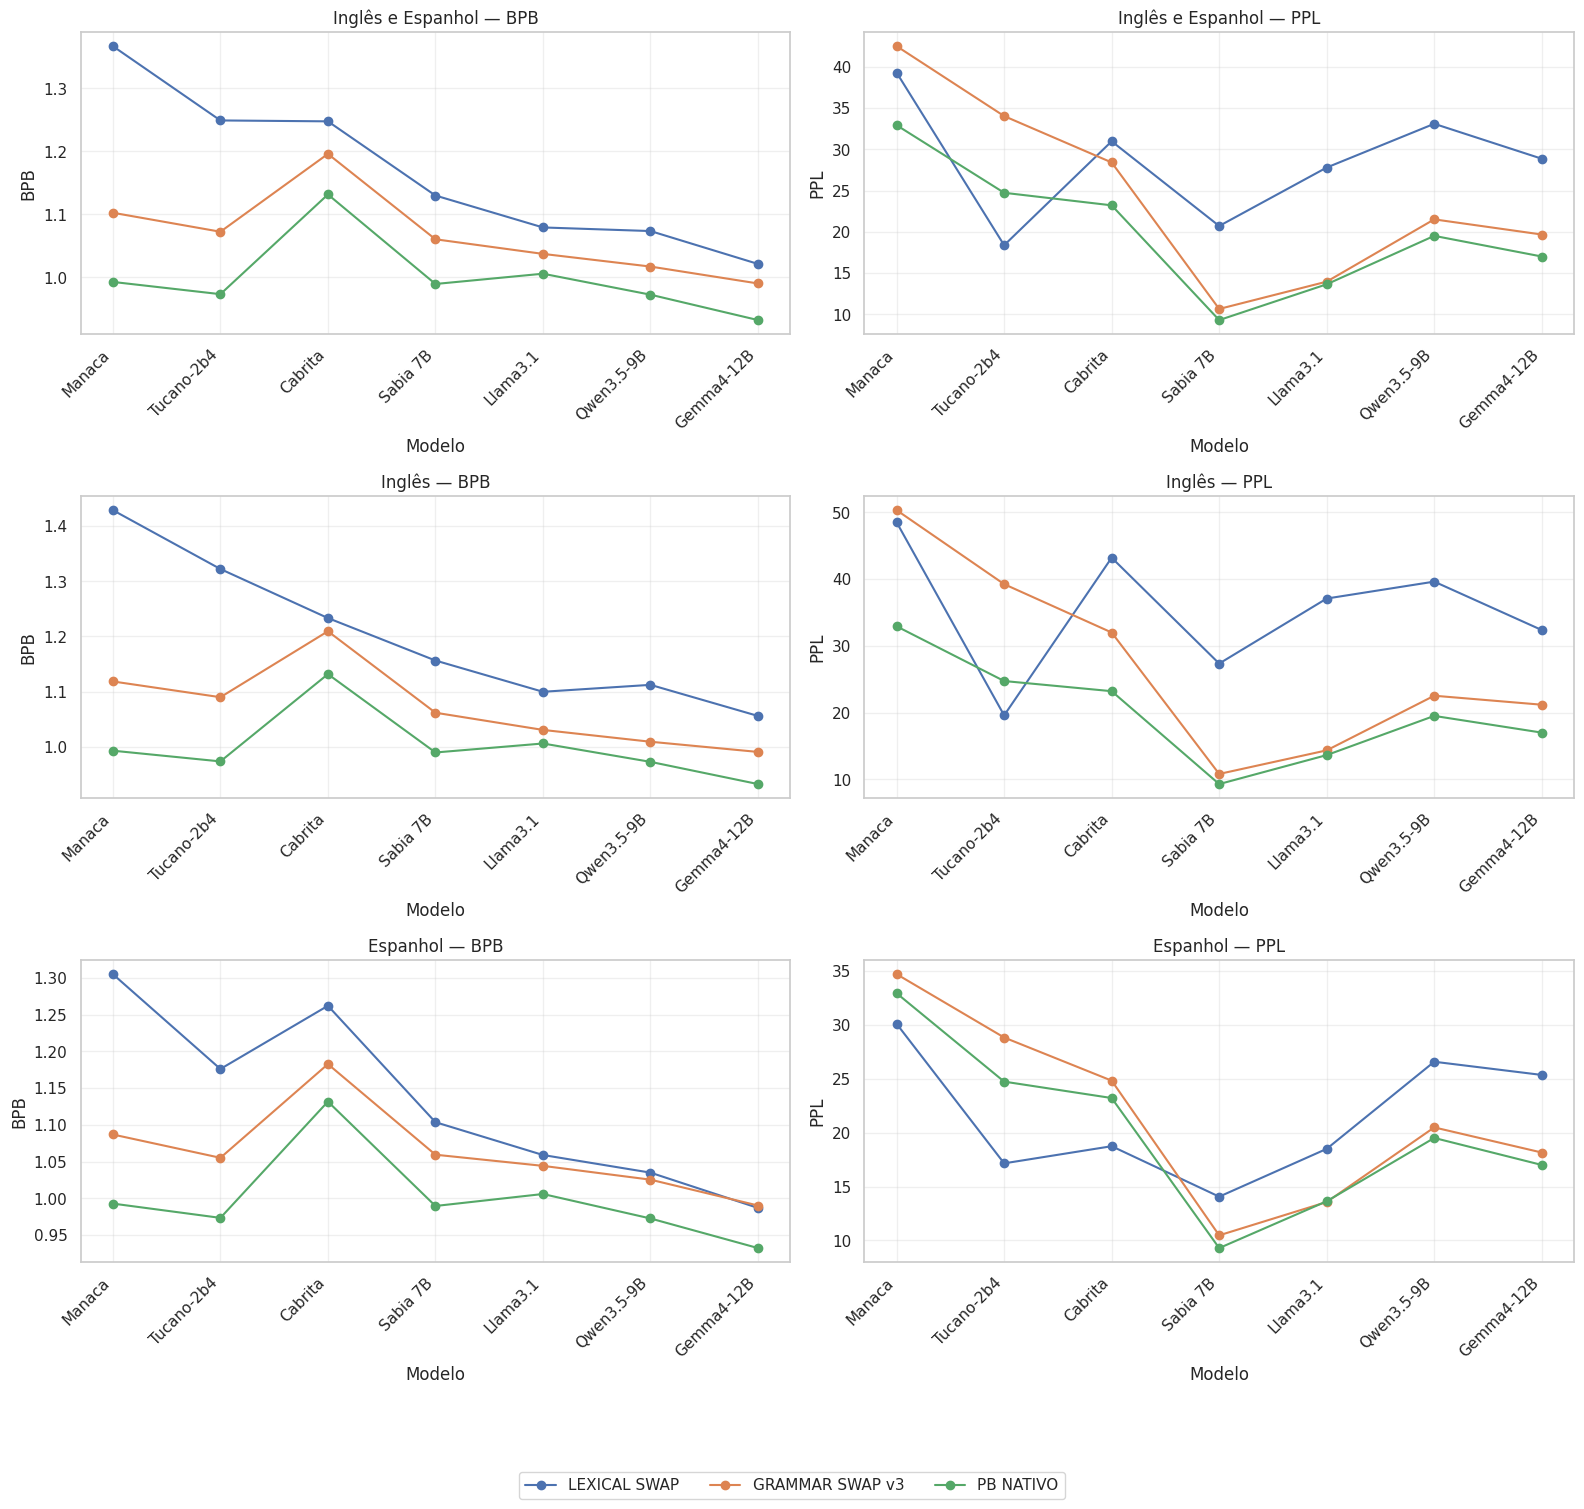

In [25]:
plot_results(scenarios =["LEXICAL SWAP", "GRAMMAR SWAP v3", "PB NATIVO"])

BPB
- O invariante do grammar SWAP é a forma de escrita da língua (léxico)
- Os modelos apresentam mais dificuldades quando troca o léxico do que a gramática
- Tendem a entender mais a estrutura superficial da linguagem
    - Exceção: Gemma para o espanhol


PPL
- Os modelos em português preferem o a estrutura da língua mantida - Lexical swap menor, invariante é a gramatica
- Quando os modelos passam a ser bilingues e multilíngues, eles passam a preferir o léxico do que a gramática
- Como se o modelo identificasse o sistema de escrita, mas não conseguisse decifrar qual regra seguir 


**Por que o PPL prefere o texto traduzido mesmo para modelos monolíngues??**